Title: Understanding the drivers of customer churn and identifying actionable retention strategies for the bank: A Data-Driven Approach Using Kaggle’s Bank Customer Dataset For A Multinational Bank (2018 -2022)


Name: Chizoma Chidiebube Chikere

Student ID: ALT/SOD/025/3551

## 1. INTRODUCTION
In today’s competitive banking industry, customer loyalty is fragile. Every time a customer leaves, the bank loses not only revenue but also trust. This reality makes customer churn one of the most critical challenges banks face, and understanding the reasons behind it is essential for designing effective retention strategies.

Customer churn refers to the situation where customers stop using a company’s services. In the banking sector, churn has a direct impact on profitability, customer lifetime value, and long-term sustainability.

Retaining existing customers is often more cost-effective than acquiring new ones. Therefore, understanding the drivers of churn is critical for improving customer retention strategies.

## 2. PROBLEM STATEMENT
Despite the importance of customer retention, many banks struggle to identify which customers are most at risk of leaving. Traditional marketing approaches often fail to capture the complex patterns behind churn, leading to ineffective campaigns and wasted resources. My project seeks to explore how data science can help predict churn before it happens, using a real-world dataset of 10,000 bank customers from a multination Bank between the year 2018 - 2022. By analyzing features like credit score, tenure, and activity status, I seek to uncover the hidden signals that tell us who is at risk of leaving and how banks can act before it’s too late. 

The primary business question is:
What factors influence customer churn, and how can the bank reduce customer attrition?

## 3. DATASET 📂
The dataset use for this project is gotten from Kaggle a leading platform for open data and machine learning competitions. Specifically, I used the Bank Customer Churn dataset published by Radheshyam Kollipara. This dataset contains records of 10,000 bank customers, including demographic details, account information, and whether the customer exited (churned) or remained with the bank.
I choose this dataset because it is both recent and relevant (2018-2022) to modern banking practices. Unlike older datasets such as the 2013 Bank Marketing dataset, this one reflects current customer attributes like credit score, tenure, balance, and activity status. These features allow for a more realistic analysis of churn behavior in today’s financial industry.

| Column           | Description                                                          | Data Type | Type                                     |
|------------------|----------------------------------------------------------------------|-----------|------------------------------------------|
| RowNumber        | Sequential row number assigned to each customer record               | int64     | Identifier                               |
| CustomerId       | Unique identification number for each customer                       | int64     | Identifier                               |
| Surname          | Customer’s Last name                                                 | object    | Categorical (Nominal)                    |
| CreditScore      | Customer’s Credit score                                              | int64     | Numerical (Discrete)                     |
| Geography        | Customer’s Country/location                                          | object    | Categorical (Nominal)                    |
| Gender           | Customer’s Gender                                                    | object    | Categorical (Nominal)                    |
| Age              | Customer’s Age in years                                              | int64     | Numerical (Continuous)                   |
| Tenure           | Number of years the customer has stayed with the bank                | int64     | Numerical (Discrete)                     |
| Balance          | Customer’s Account balance                                           | float64   | Numerical (Continuous)                   |
| NumOfProducts    | Number of bank products used by the customer                         | int64     | Numerical (Discrete)                     |
| HasCrCard        | Whether the customer has a credit card (0 = No, 1 = Yes)             | int64     | Categorical (Binary)                     |
| IsActiveMember   | Whether the customer is an active member (0 = No, 1 = Yes)           | int64     | Categorical (Binary)                     |
| EstimatedSalary  | Estimated annual salary of the customer                              | float64   | Numerical (Continuous)                   |
| Exited           | Whether the customer left the bank (0 = No, 1 = Yes)                 | int64     | Target Variable (Binary Classification)  |

## 4. OBJECTIVES
- Identify the factors contributing to customer churn and provide actionable recommendations that can improve customer retention.
- Develop a simple predictive model that can identify customers at risk of leaving.

1. Identify patterns and trends among churned customers
2. Understand key factors associated with customer churn
3. Build insights that can support retention strategies
4. Develop a simple predictive model to identify at-risk customers



## 5. TARGET VARIABLE
The target variable in this dataset is 'Exited', which indicates whether a customer has churned (1) or not (0).

Customer churn refers to the situation where customers stop using a company’s services. In the banking sector, churn has a direct impact on profitability, customer lifetime value, and long-term sustainability.

Retaining existing customers is often more cost-effective than acquiring new ones. Therefore, understanding the drivers of churn is critical for improving customer retention strategies.

In [61]:
#Importing the needed libraries for this project


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


sns.set(style="whitegrid")

In [2]:
#Loading the dateset

Cust_churn_record = pd.read_csv('Customer-Churn-Records.csv')

#Viewing the first 5 rows and all the columns of the dataset
Cust_churn_record.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## DATASET CLEANING AND PREPROCESSING

This phase consist of 
- Identifying the dimensions of the dataset
- Checking if there are wrong datatypes in the dataset
- Identifying missing variables
- Checking class balance of the dataset
- Feature engineering
- Dropping unnecesarry columns
- Identifying the numerical and categorical variables as well as converting some of the categorical variables into numbers for easy machine understanding.

In [3]:
#Checking the dimension of the dataset

print("---DATA SUMMMARY---")
print(f"Total Records (Rows):{Cust_churn_record.shape[0]}")
print(f"Total Variables (Column): {Cust_churn_record.shape[1]}")

---DATA SUMMMARY---
Total Records (Rows):10000
Total Variables (Column): 18


In [4]:
#Checking for wrong data type

Cust_churn_record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

Interpretation: All columns are in the right data types

In [5]:
#Checking if there are missing any variables in the dataset

print("---MISSING VARIABLES---")
print(Cust_churn_record.isnull().sum())

---MISSING VARIABLES---
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [6]:
Cust_churn_record["Exited"].value_counts(normalize=True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

Interpretation:
The above output indicates that approximately 80% of the customers are retained while 20% of customers churn.

This imbalance reflects a typical real-world banking scenario where customer retention is generally high.

However, this imbalance must be considered during model evaluation, as accuracy alone may not be sufficient. Instead, metrics such as precision, recall, and F1-score will provide better insight into model performance, particularly for identifying churned customers.

In [7]:
# Feature Engineering: I will be creating a new column for the Age column 


Cust_churn_record["AgeGroup"] = pd.cut(
    Cust_churn_record["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-40", "40-50", "50-60", "60+"]
)




Cust_churn_record["TenureGroup"] = pd.cut(
    Cust_churn_record["Tenure"],
    bins=[-1, 2, 6, 10],
    #labels=["New (0-2)", "Mid (3-6)", "Long (7-10)"]
    labels=["New Customer", "Mid Customer", "Long-term Customer"]
)

Cust_churn_record.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,AgeGroup,TenureGroup
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,40-50,New Customer
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,40-50,New Customer
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,40-50,Long-term Customer
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,30-40,New Customer
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,40-50,New Customer


In [8]:
# Identifying the Numerical and Categorical Columns

num_cols = Cust_churn_record.select_dtypes(include=['int64', 'float64']).columns
cat_cols = Cust_churn_record.select_dtypes(include=['object', 'category']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Point Earned'],
      dtype='object')

Categorical Columns:
Index(['Surname', 'Geography', 'Gender', 'Card Type', 'AgeGroup',
       'TenureGroup'],
      dtype='object')


In [9]:
# Dropping unnecessary columns such as RowNumber, CustomerId, and Surname as they will have no effect of my analysis

Cust_churn_record = Cust_churn_record.drop(columns=["RowNumber", "CustomerId", "Surname"])

Cust_churn_record.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,AgeGroup,TenureGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,40-50,New Customer
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,40-50,New Customer
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,40-50,Long-term Customer
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,30-40,New Customer
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,40-50,New Customer


In [10]:
# Converting our Categorical variables into numbers for easy ML understanding(Encoding)

#For the Gender Column: Let Female = 1 and Male = 0

Cust_churn_record["Gender"] = Cust_churn_record["Gender"].map({"Male": 0, "Female": 1})


In [11]:
#For the Geography column

Cust_churn_record = pd.get_dummies(Cust_churn_record, columns=["Geography"], drop_first=False)

In [12]:
#For Card Type 
Cust_churn_record = pd.get_dummies(Cust_churn_record, columns=["Card Type"], drop_first=True)

In [13]:
Cust_churn_record.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,...,Satisfaction Score,Point Earned,AgeGroup,TenureGroup,Geography_France,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,1,42,2,0.00,1,1,1,101348.88,1,...,2,464,40-50,New Customer,True,False,False,False,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,...,3,456,40-50,New Customer,False,False,True,False,False,False
2,502,1,42,8,159660.80,3,1,0,113931.57,1,...,3,377,40-50,Long-term Customer,True,False,False,False,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,...,5,350,30-40,New Customer,True,False,False,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,...,5,425,40-50,New Customer,False,False,True,True,False,False


**Interpretation:**
After encoding the categorical variables, the dataset now represents non-numeric features in a machine-readable format suitable for modeling. Columns such as Geography and Card Type were transformed into multiple binary indicator variables (one-hot encoding). This is why values like True and False appear in the dataset.
True indicates that a particular category is present for that observation.
False indicates that the category is not present.

For example:

If Geography_Spain is True, it means the customer is from Spain.
If it is False, it means the customer is not from Spain.

If ard Card_Type_GOLD is True, it means the customer is has a Gold card type.
If it is False, it means the customer does not have a Gold card type
vice versa

This transformation allows machine learning models to process categorical data without assuming any ordinal relationship between categories. Each category is treated independently, improving model interpretability and performance.

In [14]:
#Saving my cleaned dataset

Cust_churn_record.to_csv("cleaned_churn_data.csv", index=False)

In [15]:
# Loading my cleaned dataset

Cust_churn_cleaned = pd.read_csv("cleaned_churn_data.csv")

Cust_churn_cleaned.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,...,Satisfaction Score,Point Earned,AgeGroup,TenureGroup,Geography_France,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,1,42,2,0.00,1,1,1,101348.88,1,...,2,464,40-50,New Customer,True,False,False,False,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,...,3,456,40-50,New Customer,False,False,True,False,False,False
2,502,1,42,8,159660.80,3,1,0,113931.57,1,...,3,377,40-50,Long-term Customer,True,False,False,False,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,...,5,350,30-40,New Customer,True,False,False,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,...,5,425,40-50,New Customer,False,False,True,True,False,False


In [16]:
print("---DATA SUMMMARY---")
print(f"Total Records (Rows):{Cust_churn_cleaned.shape[0]}")
print(f"Total Variables (Column): {Cust_churn_cleaned.shape[1]}")

---DATA SUMMMARY---
Total Records (Rows):10000
Total Variables (Column): 21


In [17]:
print("---MISSING VARIABLES--")
print(Cust_churn_cleaned.isnull().sum())

---MISSING VARIABLES--
CreditScore           0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Point Earned          0
AgeGroup              0
TenureGroup           0
Geography_France      0
Geography_Germany     0
Geography_Spain       0
Card Type_GOLD        0
Card Type_PLATINUM    0
Card Type_SILVER      0
dtype: int64


## EXPLORATORY DATA ANALYSIS

This phase focuses on understanding the characteristics of the dataset through descriptive statistics and data visualization. The objective is to identify patterns, trends, and potential drivers of customer churn that will support feature selection and model development.


In [18]:
#Checking the distribution of our Target Variable (Exited)

Cust_churn_cleaned['Exited'].value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

Interpretation: This count shows that 7962 customers were retained by the bank while 2038 customers churned

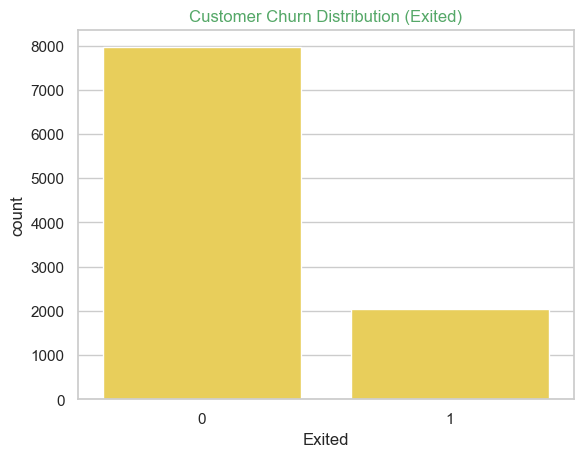

In [19]:
#Visualizing the above using Boxplot

sns.countplot(x='Exited', data=Cust_churn_cleaned, color='#FFDD44')
plt.title('Customer Churn Distribution (Exited)', color='g')

plt.show()

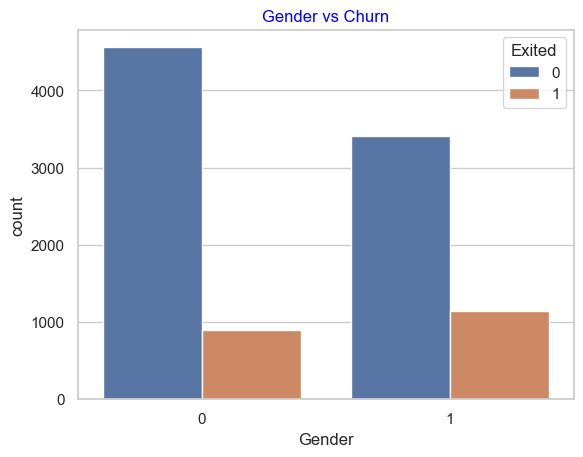

In [20]:
#Comparing Churn behaviour among the genders to ascertain if gender is a strong predictor of customer churn.


sns.countplot(x='Gender', hue='Exited', data=Cust_churn_cleaned)
plt.title('Gender vs Churn',color='blue')
plt.show()

Interpretation:
From the plot above, it indicates that there are more Female (1) customers who churned than male(0) customers. Also more male cstomers were reatined than female customers with male retained at over 4000 and female 3000 plus customers.

Gender does not show a strong separation in churn behavior. While there are minor differences in churn proportions between the two groups, it is unlikely to be a dominant predictor on its own. This suggests that other variables such as age, geography, or account activity may have stronger influence on customer churn.

In [21]:
#Comparing Churn behaviour to the customers geography to ascertain if gender is a strong predictor of customer churn.


#Beacuse I have one hot coded the geaography column during my data cleaning and preprocessing stage, I want to create a new column to enable me identify the churn rate with regards to customers location( Geography_Spain or Geography_Germany) 
geo_cols = ['Geography_France', 'Geography_Germany', 'Geography_Spain']

Cust_churn_cleaned_geo = Cust_churn_cleaned[geo_cols + ['Exited']]

Cust_churn_cleaned_geo.groupby(['Exited'])[geo_cols].sum()

,Geography_France,Geography_Germany,Geography_Spain
Exited,,,
0,4203,1695,2064
1,811,814,413


Interpretation:

There are more customers who churned in Germany with 814  count compare to Spain 413 and France 811. But more customers where retain in France and Spain than Germany.

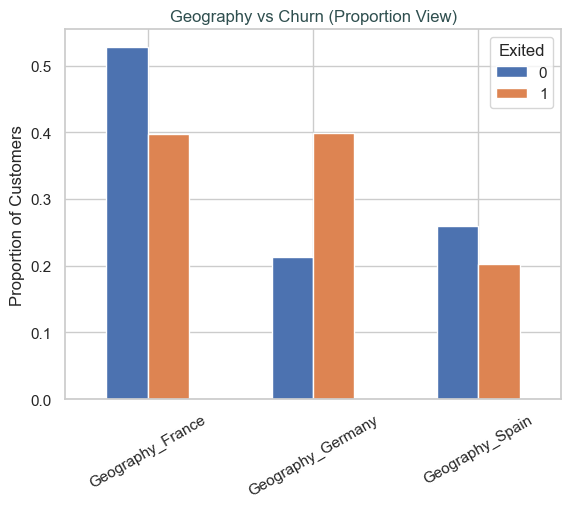

In [22]:
#Visualizing the Geaography vs Churn ratio

Cust_churn_cleaned_geo = Cust_churn_cleaned[['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Exited']]

Cust_churn_cleaned_geo.groupby('Exited')[['Geography_France','Geography_Germany', 'Geography_Spain']].mean().T.plot(kind='bar')

plt.title('Geography vs Churn (Proportion View)', color='DarkSlateGrey')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=30)
plt.show()

Interpretaion:

From the visual above,Customers from Germany and France exhibit higher churn rates, indicating location may be an important predictor of customer retention behavior.

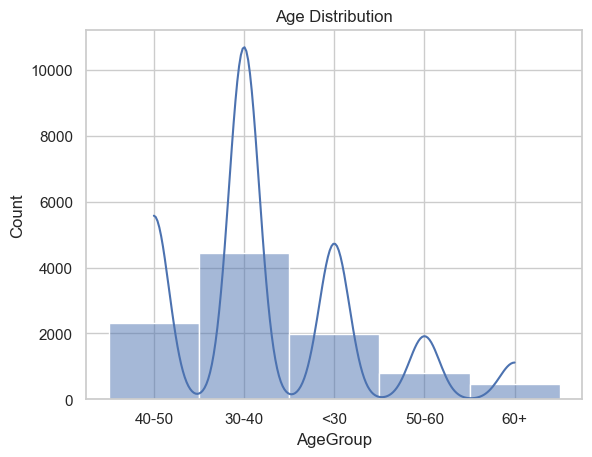

In [23]:
#Identifying the Age Distribution
sns.histplot(Cust_churn_cleaned['AgeGroup'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

Interpretation:

This shows the age spread of customers. With most of the customer within AgeGroup 30 - 40 years, followed by 40 - 50 years while the least customer by age are the 60+

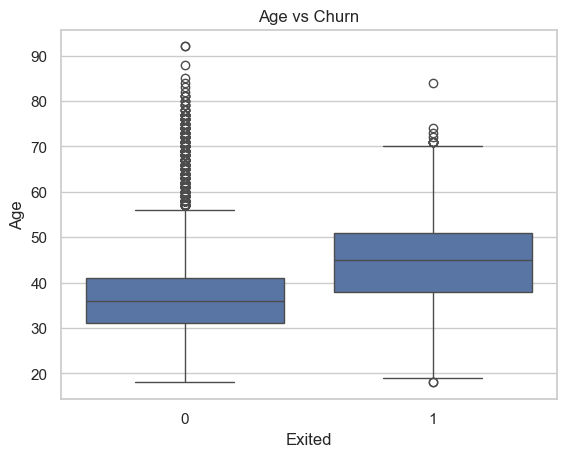

In [24]:
#Comparing Age Distribution to Churn; Visualising using a boxplot

sns.boxplot(x='Exited', y='Age', data=Cust_churn_cleaned)
plt.title('Age vs Churn')
plt.show()

In [25]:
age_churn_rate = pd.crosstab(
    Cust_churn_cleaned['AgeGroup'],
    Cust_churn_cleaned['Exited'],
    normalize='index'
) * 100

age_churn_rate

Exited,0,1
AgeGroup,,
30-40,87.890362,12.109638
40-50,66.034483,33.965517
50-60,43.789210,56.210790
60+,75.215517,24.784483
<30,92.479675,7.520325


Interpretation:

The boxplot and analysis above reveals a notable difference in age distribution between churned and retained customers. Customers who exited the bank tend to be older, with a median age of approximately 45 years compared to about 36 years for retained customers. The distribution of ages among churned customers is consistently higher, suggesting that age may be an important factor influencing customer attrition. This finding indicates that older customers may require targeted retention strategies to improve loyalty and reduce churn

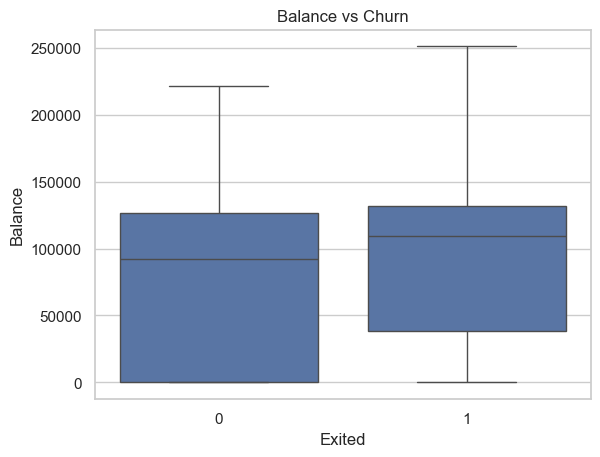

In [26]:
#Comparing Balance vs Churn

sns.boxplot(x='Exited', y='Balance', data=Cust_churn_cleaned)
plt.title('Balance vs Churn')
plt.show()

Interpretaion: 

Customers who churn tend to have slightly higher account balances than those who stay (median and upper quartile are a bit higher for churners), but the distributions overlap a lot. Which implies that balance alone is a weak predictor.

In order to review patterns, I will be combining Balances with with engagement or product mix (e.g. balance-to-salary ratio, inactivity)

In [27]:
# I will be creating a few, interpretable features that mix balance with ability/engagement. .

#Feature engineering:

fe = Cust_churn_cleaned.copy()

# 1) Balance-to-salary ratio (ability to move funds vs. attachment)
fe["BalToSalary"] = fe["Balance"] / (fe["EstimatedSalary"] + 1e-6)

# for interpretability
fe["BalToSalaryBucket"] = pd.cut(
    fe["BalToSalary"],
    bins=[-0.01, 0.25, 0.75, 1.5, np.inf],
    labels=["Very low", "Low", "Medium", "High"]
)

# 2) High balance flag (top quartile) — combine later with engagement
q75 = fe["Balance"].quantile(0.75)
fe["HighBalance"] = (fe["Balance"] >= q75).astype(int)

# 3) Inactive-high-balance interaction (high risk if disengaged but valuable)
fe["Inactive_HighBal"] = ((fe["IsActiveMember"] == 0) & (fe["HighBalance"] == 1)).astype(int)

# 4) Simple product richness flag (if NumOfProducts exists)
if "NumOfProducts" in fe.columns:
    fe["ProductRich"] = (fe["NumOfProducts"] >= 3).astype(int)  # adjust threshold if needed


C:\Users\Chizoma.Chikere\AppData\Local\Temp\ipykernel_3312\1198456753.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Cust_churn_cleaned.groupby(col)["Exited"]


,BalToSalaryBucket,churn_rate,n,churners,churn_rate_pct
1,Low,0.246734,1378,340,24.7
3,High,0.241584,2525,610,24.2
2,Medium,0.235677,2461,580,23.6
0,Very low,0.139714,3636,508,14.0


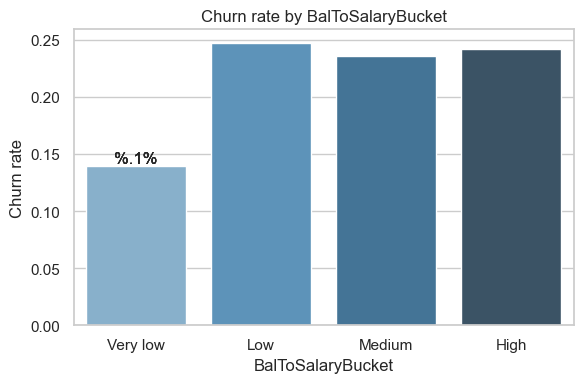

,HighBalance,churn_rate,n,churners,churn_rate_pct
1,1,0.2368,2500,592,23.7
0,0,0.1928,7500,1446,19.3


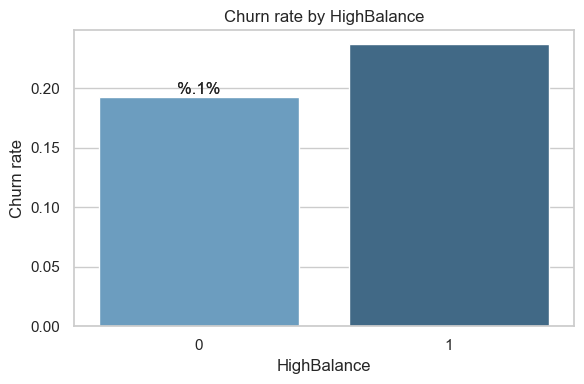

,Inactive_HighBal,churn_rate,n,churners,churn_rate_pct
1,1,0.304731,1247,380,30.5
0,0,0.189421,8753,1658,18.9


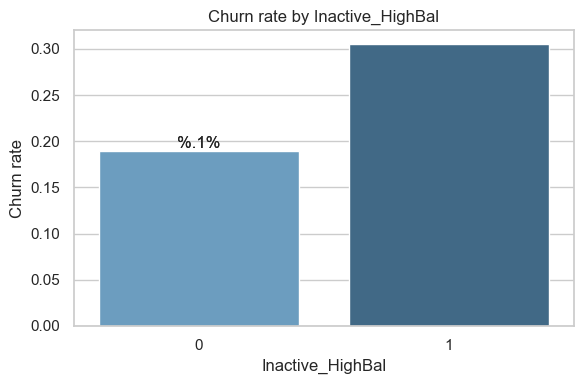

,ProductRich,churn_rate,n,churners,churn_rate_pct
1,1,0.858896,326,280,85.9
0,0,0.181724,9674,1758,18.2


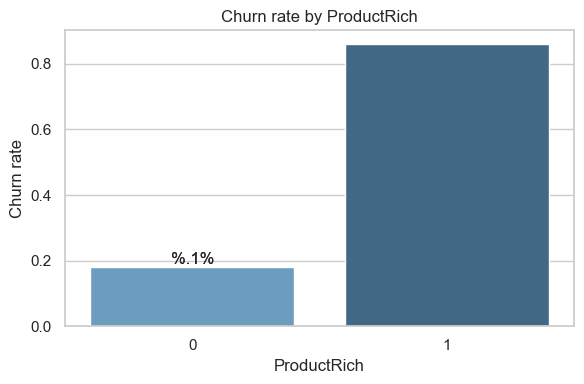

In [28]:
def churn_table(Cust_churn_cleaned, col):
    out = (
        Cust_churn_cleaned.groupby(col)["Exited"]
        .agg(churn_rate="mean", n="count", churners="sum")
        .reset_index()
        .sort_values("churn_rate", ascending=False)
    )
    out["churn_rate_pct"] = (out["churn_rate"] * 100).round(1)
    return out


for col in ["BalToSalaryBucket", "HighBalance", "Inactive_HighBal", "ProductRich"]:
    if col in fe.columns:
        
        table = churn_table(fe, col)   # compute ONCE
        display(table)

        if fe[col].nunique() <= 6:
            plt.figure(figsize=(6,4))
            ax = sns.barplot(
                data=table,
                x=col,
                y="churn_rate",
                hue=col,
                palette="Blues_d",
                legend=False
            )

    

            # safer labeling (uses same table)
            for container in ax.containers:
                ax.bar_label(ax.containers[0], fmt="%.1%")
                
            plt.title(f"Churn rate by {col}")
            plt.ylabel("Churn rate")
            plt.xlabel(col)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()

Interpretation of Churn Segmentation Results

This analysis explores how different engineered customer segments relate to churn behavior using churn rate, sample size, and churn counts.

---
 1. BalToSalaryBucket vs Churn

Customers with a very low balance-to-salary ratio show the lowest churn rate at **14.0%**, indicating strong stability in this group.

All other categories (Low, Medium, High) have relatively similar churn rates around **23.6%–24.7%**, suggesting that beyond the “very low” group, balance-to-salary ratio does not strongly differentiate churn risk.

**Key insight:**
Only the “very low” segment is meaningfully different, while the rest form a relatively uniform moderate-risk group.

---

 2. HighBalance vs Churn

Customers with high balances exhibit a higher churn rate (**23.7%**) compared to those without high balances (**19.3%**).

This indicates that having a high account balance does not guarantee retention. Instead, high-balance customers may be more sensitive to competing offers or less engaged with the bank.

**Key insight:**
High balance alone is not a loyalty indicator and may instead reflect higher mobility risk.

---

 3. Inactive_HighBal vs Churn

This feature shows a strong separation in churn behavior:

* Inactive + high balance customers: **30.5% churn**
* Others: **18.9% churn**

This represents one of the most important risk segments in the dataset.

**Key insight:**
Customer inactivity combined with high financial value is a strong predictor of churn and indicates disengaged but valuable customers.

---

 4. ProductRich vs Churn

This feature shows an extremely strong relationship with churn:

* Product-rich customers: **85.9% churn**
* Non-product-rich customers: **18.2% churn**

This is a highly unusual and dominant pattern, suggesting either:

* Severe dissatisfaction or overload among multi-product customers, or
* A structural or definition-related issue that should be validated.

**Key insight:**
ProductRich is the strongest churn-associated feature and requires careful validation due to its extreme effect size.

---

 Overall Conclusion

Across all engineered features, churn behavior is most strongly influenced by engagement and product interaction rather than balance alone.

Key findings:

* Very low balance-to-salary customers are the most stable segment.
* High balance does not reduce churn risk and may increase it slightly.
* Inactivity combined with high balance significantly increases churn probability.
* ProductRich customers represent an extremely high-risk group and should be prioritized for further investigation.


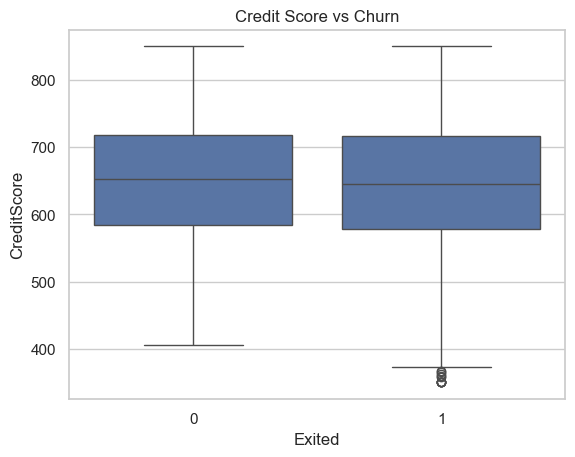

In [29]:
#Comparing Credit Score vs Churn


sns.boxplot(x='Exited', y='CreditScore', data=Cust_churn_cleaned)
plt.title('Credit Score vs Churn')
plt.show()

Interpretation:

Credit Score distributions has only a few low-score outliers among churners.This implies that creditScore alone is a weak churn signal here.

In [30]:
#Calculation the churn rate by complaint status.


complain_churn_rate = pd.crosstab(
    Cust_churn_cleaned['Complain'],
    Cust_churn_cleaned['Exited'],
    normalize='index'
) * 100

complain_churn_rate

Exited,0,1
Complain,,
0,99.949723,0.050277
1,0.489237,99.510763


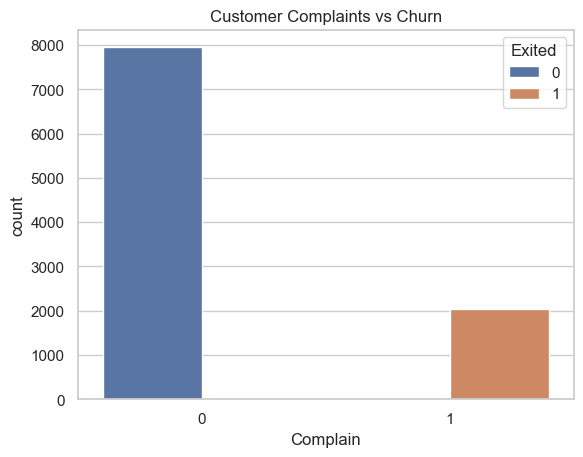

In [31]:
#Visualising the complain_churn_rate

sns.countplot(
    x='Complain',
    hue='Exited',
    data=Cust_churn_cleaned
)
plt.title('Customer Complaints vs Churn')

plt.show()

Interpretation:

The analysis reveals a very strong relationship between customer complaints and churn. Customers who did not file complaints exhibited an extremely low churn rate of approximately 0.05%, while customers who filed complaints showed a churn rate of about 99.5%. This indicates that complaints are a major predictor of customer attrition in the dataset. 

Implication:The finding suggests that unresolved service issues or ineffective complaint resolution processes may significantly contribute to customers leaving the bank

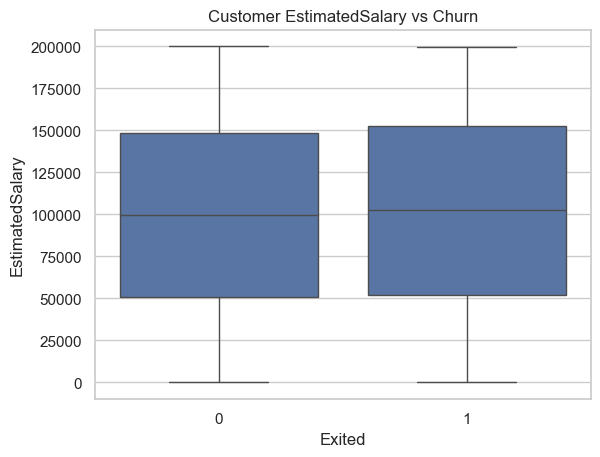

In [32]:
#Comparing Customer EstimatedSalary  vs Churn


sns.boxplot(x='Exited', y='EstimatedSalary', data=Cust_churn_cleaned)
plt.title('Customer EstimatedSalary vs Churn')
plt.show()

Interpretation:

EstimatedSalary distributions for churned and retained customers are nearly identical (medians and spread overlap heavily), indicating salary alone is not a meaningful predictor of churn in this dataset.

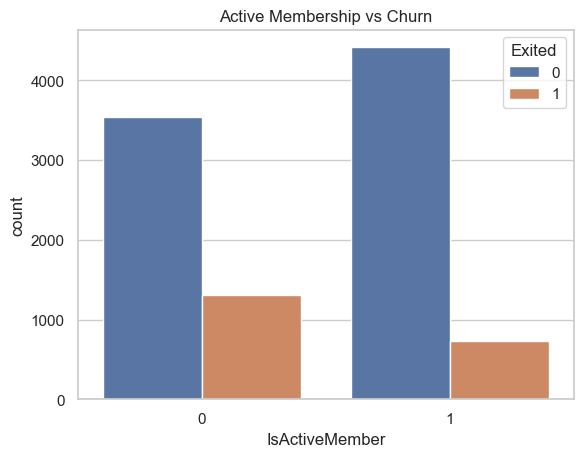

In [33]:
#Comparing Customer Active customers vs Churn: This is to detrmine if inactive customers are more likely to leave the bank

sns.countplot(x='IsActiveMember', hue='Exited', data=Cust_churn_cleaned)
plt.title('Active Membership vs Churn')
plt.show()


Interpretation:

The analysis suggests a strong relationship between customer activity status and churn. Inactive customers exhibit a noticeably higher number of churn cases compared to active customers. This indicates that customer engagement may be a key factor influencing retention. Customers who actively interact with the bank are more likely to remain, whereas inactive customers may require targeted engagement initiatives to reduce churn risk. Hence, the bank should develop re-engagement campaigns and personalized offers for inactive customers.

In [34]:
#confirming with churn rates (churners/total) to quantify the gap.

active_rates = (
    Cust_churn_cleaned.groupby("IsActiveMember")["Exited"]
         .agg(churn_rate="mean", n="count", churners="sum")
         .reset_index()
         .sort_values("IsActiveMember")
)
active_rates["churn_rate_pct"] = (active_rates["churn_rate"]*100).round(1)
active_rates


,IsActiveMember,churn_rate,n,churners,churn_rate_pct
0,0,0.268715,4849,1303,26.9
1,1,0.142691,5151,735,14.3


Interpretaion:

Inactive customers churn at 26.9% vs. 14.3% for active customers, there is a gap of 12.6%.
This implies that boosting engagement such as reactivation nudges, targeted offers, usage prompts is a high-impact lever for reducing churn.

In [35]:
#Comparing NumOfProducts per customers vs Churn: This is to determine if using more products reduce churn.

#Checking the percentage of customers in each product group churn
product_churn_rate = pd.crosstab(
    Cust_churn_cleaned['NumOfProducts'],
    Cust_churn_cleaned['Exited'],
    normalize='index'
) * 100

product_churn_rate

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.396514,7.603486
3,17.293233,82.706767
4,0.000000,100.000000


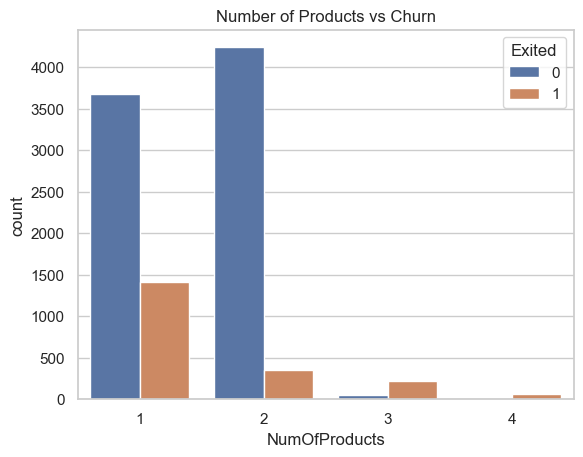

In [36]:
#Visualising NumOfProducts per customers vs Churn

sns.countplot(x='NumOfProducts', hue='Exited', data=Cust_churn_cleaned)
plt.title('Number of Products vs Churn')

plt.show()

In [37]:
Cust_churn_cleaned['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Interpretation:


The visual above suggests that product ownership appears to have a significant relationship with customer churn. Customers holding two banking products exhibited the lowest churn rate (7.6%), while customers with only one product experienced a substantially higher churn rate (27.7%). This suggests that customers who engage with multiple banking services tend to be more loyal and less likely to leave the bank. Although customers with three and four products displayed exceptionally high churn rates (82.7% and 100%, respectively), these groups represent a relatively small portion of the customer base. Overall, the findings indicate that increasing product adoption may strengthen customer engagement and improve retention outcomes.

Recommendation: The bank should implement cross-selling and product bundling initiatives targeted at single-product customers. Encouraging customers to adopt additional banking services may increase engagement, strengthen customer relationships, and reduce churn.

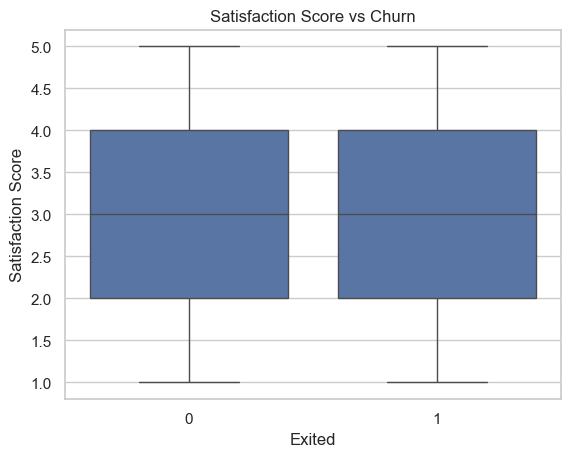

In [38]:
#Comparing Satisfaction Score vs Churn: This is to determine if dissatisfied customers are leaving more frequently

sns.boxplot(x='Exited', y='Satisfaction Score', data=Cust_churn_cleaned)
plt.title('Satisfaction Score vs Churn')

plt.show()

In [39]:
#Checking for the mean of customers satisfaction score

Cust_churn_cleaned.groupby('Exited')['Satisfaction Score'].mean()

Exited
0    3.017960
1    2.997547
Name: Satisfaction Score, dtype: float64

Interpretaion:

The analysis revealed very little difference in satisfaction scores between customers who remained with the bank and those who churned. The average satisfaction score for retained customers was 3.02, compared to 3.00 for churned customers. Similarly, the boxplot showed nearly identical distributions across both groups. These findings suggest that satisfaction score is not a strong predictor of customer churn within this dataset. Therefore, other factors such as customer complaints, activity status, product ownership, and account characteristics are likely to have a greater influence on customer retention.

In [40]:
active_churn_rate = pd.crosstab(
    Cust_churn_cleaned['IsActiveMember'],
    Cust_churn_cleaned['Exited'],
    normalize='index'
) * 100

active_churn_rate



active_rates = (
    Cust_churn_cleaned.groupby("IsActiveMember")["Exited"]
         .agg(churn_rate="mean", n="count", churners="sum")
         .reset_index()
         .sort_values("IsActiveMember")
)
active_rates["churn_rate_pct"] = (active_rates["churn_rate"]*100).round(1)
active_rates

,IsActiveMember,churn_rate,n,churners,churn_rate_pct
0,0,0.268715,4849,1303,26.9
1,1,0.142691,5151,735,14.3


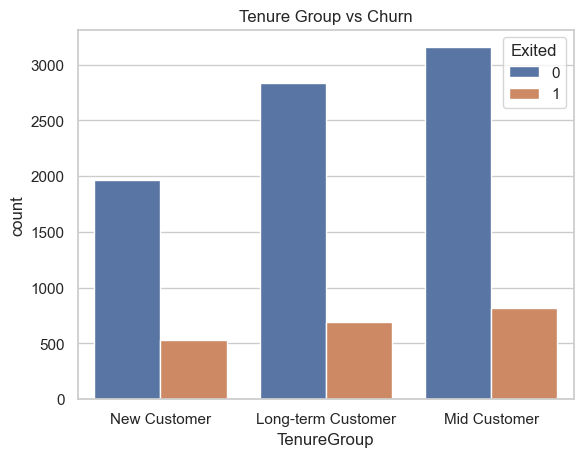

In [41]:
#Comparing Tenure vs Churn: This is to see if  newer customers are more likely to churn

sns.countplot(x='TenureGroup', hue='Exited', data=Cust_churn_cleaned)
plt.title('Tenure Group vs Churn')

plt.show()

In [42]:
#The chart above shows counts; confirming with churn rates per group to validate the pattern

tenure_rates = (
    Cust_churn_cleaned.groupby("TenureGroup")["Exited"]
         .agg(churn_rate="mean", n="count", churners="sum")
         .reset_index()
         .sort_values("churn_rate", ascending=False)
)
tenure_rates["churn_rate_pct"] = (tenure_rates["churn_rate"]*100).round(1)
tenure_rates


,TenureGroup,churn_rate,n,churners,churn_rate_pct
2,New Customer,0.211538,2496,528,21.2
1,Mid Customer,0.206437,3977,821,20.6
0,Long-term Customer,0.195350,3527,689,19.5


Interpretation;

From the countplot above, mid‑tenure customers (3–6 years) show the most churners, suggesting churn peaks in the middle of the customer lifecycle—not at the very start. This points to a key retention window around years 3–6 for proactive outreach and benefit refreshes.

Churn rates are highest for New (0–2 yrs) at 21.2%, followed by Mid (3–6 yrs) at 20.6%, and lowest for Long (7–10 yrs) at 19.5%.

Insight: Risk is elevated early and remains high through years 3–6 before easing for long‑tenure customers.

Implication: The bank should prioritize onboarding/early engagement and a mid‑tenure retention check‑in program.

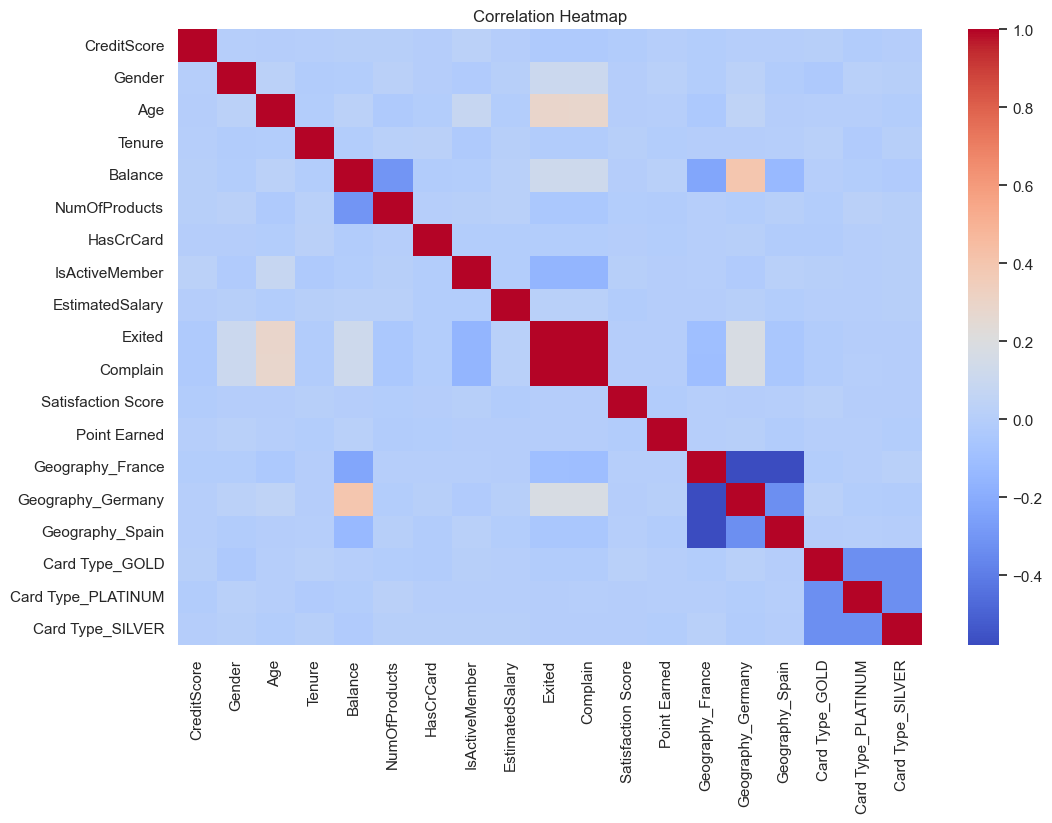

In [43]:
#Correlation Heat Map

plt.figure(figsize=(12,8))
sns.heatmap(Cust_churn_cleaned.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

<h1 align="center">Key Finding Summary</h1>

The exploratory data analysis revealed several important factors associated with customer churn. These findings provide valuable insights into customer behavior and highlight areas where the bank can focus its retention efforts.

**Key Finding 1:** Customer Complaints are the Strongest Indicator of Churn.
Customer complaints exhibited the strongest relationship with churn among all variables analyzed. Customers who did not file complaints had a churn rate of only 0.05%, whereas customers who filed complaints had a churn rate of approximately 99.5%. This suggests that complaints serve as a critical warning sign of customer dissatisfaction and potential attrition.

Business Implication: Improving complaint resolution processes and customer support services could significantly reduce customer churn and improve customer retention.

---

**Key Finding 2:** Age Has a Significant Impact on Customer Churn.
Customer churn was found to increase with age. Customers below the age of 30 recorded the lowest churn rate (7.5%), while customers aged 50–60 experienced the highest churn rate (56.2%). This indicates that middle-aged and older customers are more likely to leave the bank compared to younger customers.

Business Implication: The bank should consider implementing targeted retention strategies and personalized engagement programs for customers in higher-risk age groups.

---

**Key Finding 3:** Product Adoption Improves Customer Retention.
The number of products owned by customers showed a strong relationship with churn behavior. Customers with two products recorded the lowest churn rate (7.6%), compared to customers with one product who experienced a churn rate of 27.7%. This suggests that customers who utilize multiple banking services tend to have stronger relationships with the bank and are less likely to leave.

Business Implication: Cross-selling and product bundling initiatives may help strengthen customer loyalty and reduce churn among single-product customers.

---

**Key Finding 4:** Customer Engagement Reduces Churn Risk.
Active customers were significantly less likely to churn than inactive customers. The churn rate among inactive customers was 26.9%, compared to 14.3% for active customers. This indicates that customer engagement plays an important role in customer retention.

Business Implication: The bank should develop customer engagement and reactivation campaigns aimed at increasing customer activity and strengthening customer relationships.

---

**Key Finding 5:** Geographic Differences Exist in Customer Churn.
The analysis revealed differences in churn behavior across geographic regions, indicating that customer retention challenges may vary by location. Some regions experienced higher churn levels than others, suggesting that regional factors may influence customer decisions.

Business Implication: The bank should investigate regional drivers of churn and tailor retention strategies to specific geographic markets where customer attrition is highest.

---
**Key Finding 6:** Customer Balance Appears to Influence Churn.
Customers with higher account balances generally exhibited higher churn tendencies compared to customers with lower balances. This finding suggests that some of the bank's higher-value customers may be at greater risk of leaving.

Business Implication: Retaining high-balance customers should be a strategic priority, as losing these customers could have a significant financial impact on the bank.

---

**Key Finding 7:** Satisfaction Score Shows limited Influence on Churn.
Contrary to expectations, customer satisfaction scores showed very little difference between churned and retained customers. The average satisfaction score was approximately 3.02 for retained customers and 3.00 for churned customers. This indicates that satisfaction score alone is not a strong predictor of churn within this dataset.

Business Implication: While customer satisfaction remains important, other factors such as complaints, engagement, age, and product usage appear to play a more substantial role in influencing churn.

# Statistical Analysis & Machine Learning

This phase includes:

- Prepare data for modeling
- Split data into training and testing sets
- Build a simple churn prediction model
- Evaluate model performance
- Identify important churn predictors
- Connect model findings to EDA findings

In [44]:
# Feature selection


# My Target Variabele (y) will be Exited

y = Cust_churn_cleaned['Exited']



# while my X variable will be 
X = Cust_churn_cleaned.drop(
    columns=[
        'Exited',
        'AgeGroup',
        'TenureGroup'
    ]
)

In [45]:
y.value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [46]:
# Creating Train and Test dataset using a test size of 0.2 building the machine learning model

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
# Verifying the split dataset


print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train distribution")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution")
print(y_test.value_counts(normalize=True))

X_train: (8000, 18)
X_test : (2000, 18)

y_train distribution
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

y_test distribution
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


Outcome:

The train-test split successfully preserved the original class distribution of the target variable through stratified sampling. Approximately 79.6% of observations in both the training and testing datasets represent retained customers, while 20.4% represent churned customers. This ensures that both datasets remain representative of the overall population and reduces the risk of biased model evaluation.

<h1 align="center">Modeling </h1>

I will be developing two machine learning models and compare them.

**Model 1** will include all predictor variables, including Complain.

**Model 2** will exclude Complain because exploratory data analysis revealed an extremely strong relationship between complaints and churn, with complaint customers recording a churn rate of 99.5% compared to 0.05% for non-complaint customers. Excluding this variable allows us to evaluate how well churn can be predicted using earlier customer characteristics and behavioral indicators.

Comparing both models will help assess the impact of the Complain feature on predictive performance and identify whether churn can be detected before customers reach the complaint stage.

In [48]:
# MODEL 1 => Including complain using Logistic Regression model

# Standardising


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
#Training the model (Logistic Regression)

log_model_A = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model_A.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [50]:
#Generating prediction

y_pred_A = log_model_A.predict(X_test_scaled)

In [51]:
#Evaluating the model


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_A))
print("Precision:", precision_score(y_test, y_pred_A))
print("Recall   :", recall_score(y_test, y_pred_A))
print("F1 Score :", f1_score(y_test, y_pred_A))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_A))

print("\nClassification Report")
print(classification_report(y_test, y_pred_A))

Accuracy : 0.9985
Precision: 0.9975429975429976
Recall   : 0.9950980392156863
F1 Score : 0.996319018404908

Confusion Matrix
[[1591    1]
 [   2  406]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Interpretation of Model 1 Performance:

The Logistic Regression model achieved an accuracy of 99.85%, with a precision of 99.75%, recall of 99.51%, and F1-score of 99.63%. The confusion matrix indicates that the model correctly classified 1,591 retained customers and 406 churned customers, while making only three incorrect predictions.

These results demonstrate exceptionally strong predictive performance. The high precision indicates that customers predicted to churn were almost always actual churners, while the high recall shows that the model successfully identified nearly all churned customers.

The outstanding performance is likely influenced by the inclusion of the Complain feature, which was previously identified during exploratory data analysis as having an extremely strong relationship with churn. Customers who filed complaints exhibited a churn rate of approximately 99.5%, making complaints one of the most powerful predictors in the dataset.

While the model demonstrates excellent predictive capability, its performance should be interpreted with caution because the complaint variable may contain information that becomes available very close to the churn event. As a result, a second model excluding the Complain feature will be developed to assess whether customer churn can be predicted effectively using earlier customer characteristics and behavioral indicators.

**Limitation of Model 1 :** Although Model A achieved outstanding predictive performance, the inclusion of the Complain feature may have significantly influenced the results due to its extremely strong association with customer churn. Therefore, a second model excluding this feature will be developed to evaluate predictive performance using earlier customer attributes and behavioral indicators

In [52]:
# MODEL 2 => excluding complain using Logistic Regression model


# Creating a New Feature Set Without Complain

X_no_complain = Cust_churn_cleaned.drop(
    columns=[
        'Exited',
        'Complain',
        'AgeGroup',
        'TenureGroup'
    ]
)

y = Cust_churn_cleaned['Exited']

In [53]:
# Train Test spliting




X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_complain,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
#Scaling

scaler_nc = StandardScaler()

X_train_nc_scaled = scaler_nc.fit_transform(X_train_nc)
X_test_nc_scaled = scaler_nc.transform(X_test_nc)

In [55]:
#Training Logistic Regression


from sklearn.linear_model import LogisticRegression

log_model_B = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model_B.fit(X_train_nc_scaled, y_train_nc)

LogisticRegression(max_iter=1000, random_state=42)

In [56]:
y_pred_B = log_model_B.predict(X_test_nc_scaled)

In [57]:
#Model Evaluation


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test_nc, y_pred_B))
print("Precision:", precision_score(y_test_nc, y_pred_B))
print("Recall   :", recall_score(y_test_nc, y_pred_B))
print("F1 Score :", f1_score(y_test_nc, y_pred_B))

print("\nConfusion Matrix")
print(confusion_matrix(y_test_nc, y_pred_B))

print("\nClassification Report")
print(classification_report(y_test_nc, y_pred_B))

Accuracy : 0.813
Precision: 0.6231884057971014
Recall   : 0.2107843137254902
F1 Score : 0.315018315018315

Confusion Matrix
[[1540   52]
 [ 322   86]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.62      0.21      0.32       408

    accuracy                           0.81      2000
   macro avg       0.73      0.59      0.60      2000
weighted avg       0.79      0.81      0.77      2000



Interpretation of Model B Performance

The second Logistic Regression model was developed after excluding the Complain feature to assess the predictive value of earlier customer characteristics and behavioral indicators.

The model achieved an accuracy of 81.3%, precision of 62.3%, recall of 21.1%, and an F1-score of 31.5%. While the overall accuracy remained reasonably high, the recall score declined substantially compared to Model A. The model correctly identified only 86 out of 408 churned customers, indicating limited ability to detect customers at risk of leaving.

The significant reduction in performance suggests that the Complain feature contributes substantially to churn prediction. Without complaint information, customer churn becomes considerably more difficult to predict using the available variables.

Suggestion: The bank should treat customer complaints as an early warning signal and prioritize complaint resolution to reduce customer attrition

<h1 align="center"> Comparing Model A and Model B </h1>


| Metric    | Model A (With Complain) | Model B (Without Complain) |
| --------- | ----------------------: | -------------------------: |
| Accuracy  |                  99.85% |                     81.30% |
| Precision |                  99.75% |                     62.32% |
| Recall    |                  99.51% |                     21.08% |
| F1 Score  |                  99.63% |                     31.50% |


<h1 align="center"> Confusion Matrix Interpretation</h1>

| Actual / Predicted | Retained | Churn |
| ------------------ | -------: | ----: |
| Retained           |     1540 |    52 |
| Churned            |      322 |    86 |


The model is excellent at identifying retained customers.However, it struggles to identify churners. Beacuse the primary objective of a churn model is to identify customers who are likely to leave. Hence I will be using another model say the Random forest clssifier as it often performs better on nonlinear relationships.

**MODEL 3** => Including complain, using Random Forest

To explore whether a more advanced machine learning algorithm could improve predictive performance, a Random Forest classifier will be developed using all available predictor variables, including the Complain feature. Random Forest is an ensemble learning technique that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Unlike Logistic Regression, it can capture complex and non-linear relationships between customer characteristics and churn behavior.

In [62]:
#Training the Random forest

rf_model_A = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model_A.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [64]:
#Generationg Predictions

y_pred_rf_A = rf_model_A.predict(X_test)

In [65]:
#Model Evaluation


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf_A))
print("Precision:", precision_score(y_test, y_pred_rf_A))
print("Recall   :", recall_score(y_test, y_pred_rf_A))
print("F1 Score :", f1_score(y_test, y_pred_rf_A))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf_A))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf_A))

Accuracy : 0.9985
Precision: 0.9975429975429976
Recall   : 0.9950980392156863
F1 Score : 0.996319018404908

Confusion Matrix
[[1591    1]
 [   2  406]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Interpretation of Model 3 (Random Forest with Complain)

The Random Forest model achieved an accuracy of 99.85%, precision of 99.75%, recall of 99.51%, and an F1-score of 99.63%. The model correctly classified 1,997 out of 2,000 customers, making only three classification errors.

The identical performance obtained by both Logistic Regression and Random Forest suggests that the exceptional predictive accuracy is primarily driven by the Complain feature rather than the complexity of the algorithm. This indicates that complaint information contains substantial predictive power and dominates the churn prediction process.

The results further reinforce the findings from the exploratory data analysis, which identified customer complaints as the strongest indicator of churn.

Here, Random Forest ≈ Logistic Regression

In [66]:
#Before building the Random Forest model without Complain, let's extract feature importance from this model.


feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model_A.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,Complain,0.793740
2,Age,0.069604
5,NumOfProducts,0.053350
4,Balance,0.015027
7,IsActiveMember,0.012296
0,CreditScore,0.009736
8,EstimatedSalary,0.008916
11,Point Earned,0.008761
13,Geography_Germany,0.008747
3,Tenure,0.005245


<h1 align="center"> Feature Importance Analysis</h1>

| Rank | Feature        | Importance |
| ---- | -------------- | ---------: |
| 1    | Complain       |     79.37% |
| 2    | Age            |      6.96% |
| 3    | NumOfProducts  |      5.34% |
| 4    | Balance        |      1.50% |
| 5    | IsActiveMember |      1.23% |


Feature importance analysis was performed using the Random Forest model to identify the variables contributing most to churn prediction. The results revealed that Complain was by far the most influential predictor, accounting for approximately 79.4% of the model's predictive power. This finding aligns with the exploratory data analysis, which showed that customers who filed complaints were significantly more likely to churn.

Other important predictors included Age, NumOfProducts, Balance, and IsActiveMember. These variables were also identified during exploratory analysis as important factors influencing customer retention. The consistency between the EDA findings and the machine learning results increases confidence in the validity of the conclusions drawn from the study.


**MODEL 4** => Excluding complain, using Random Forest

By removing theComplain variable, we want to determine:

Whether Random Forest can uncover hidden patterns in the remaining features.
Whether it performs better than Logistic Regression without Complain.
Which customer characteristics become most important when complaint information is unavailable.

This will provides a more realistic assessment of churn prediction before customers formally complain.

In [68]:
#Training the model 


rf_model_B = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model_B.fit(X_train_nc, y_train_nc)

RandomForestClassifier(random_state=42)

In [69]:
#Generating Prediction

y_pred_rf_B = rf_model_B.predict(X_test_nc)

In [70]:
#Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test_nc, y_pred_rf_B))
print("Precision:", precision_score(y_test_nc, y_pred_rf_B))
print("Recall   :", recall_score(y_test_nc, y_pred_rf_B))
print("F1 Score :", f1_score(y_test_nc, y_pred_rf_B))

print("\nConfusion Matrix")
print(confusion_matrix(y_test_nc, y_pred_rf_B))

print("\nClassification Report")
print(classification_report(y_test_nc, y_pred_rf_B))

Accuracy : 0.868
Precision: 0.7950819672131147
Recall   : 0.47549019607843135
F1 Score : 0.5950920245398773

Confusion Matrix
[[1542   50]
 [ 214  194]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1592
           1       0.80      0.48      0.60       408

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



In [71]:
# Feature Importance


feature_importance_no_complain = pd.DataFrame({
    'Feature': X_train_nc.columns,
    'Importance': rf_model_B.feature_importances_
})

feature_importance_no_complain = feature_importance_no_complain.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_no_complain.head(10)

,Feature,Importance
2,Age,0.208621
5,NumOfProducts,0.119399
4,Balance,0.109209
8,EstimatedSalary,0.104438
10,Point Earned,0.103446
0,CreditScore,0.102254
3,Tenure,0.061558
9,Satisfaction Score,0.041066
7,IsActiveMember,0.037012
12,Geography_Germany,0.024233


**Outcome of Random Forest Without Complain (Model 4)**

| Metric    | Value |
| --------- | ----: |
| Accuracy  | 86.8% |
| Precision | 79.5% |
| Recall    | 47.5% |
| F1 Score  | 59.5% |


**Comparing Logistic Regression To Random Forest model**
| Metric    | Logistic Regression | Random Forest |
| --------- | ------------------: | ------------: |
| Accuracy  |               81.3% |         86.8% |
| Precision |               62.3% |         79.5% |
| Recall    |               21.1% |         47.5% |
| F1 Score  |               31.5% |         59.5% |


**Confusion Matrix Interpretation**
| Actual / Predicted | Retained | Churn |
| ------------------ | -------: | ----: |
| Retained           |     1542 |    50 |
| Churned            |      214 |   194 |


<h1 align="center"> Feature Importance Model 4(Random Forest without Complain Variable)</h1>

| Rank | Feature            | Importance |
| ---- | ------------------ | ---------: |
| 1    | Age                |     20.86% |
| 2    | NumOfProducts      |     11.94% |
| 3    | Balance            |     10.92% |
| 4    | EstimatedSalary    |     10.44% |
| 5    | Point Earned       |     10.34% |
| 6    | CreditScore        |     10.23% |
| 7    | Tenure             |      6.16% |
| 8    | Satisfaction Score |      4.11% |
| 9    | IsActiveMember     |      3.70% |
| 10   | Geography_Germany  |      2.42% |

Once the Complaint variable was removed, Age emerged as the most important predictor of customer churn, contributing approximately 20.9% of the model's predictive power.The machine learning model is confirming that age is a key factor influencing customer retention

**Feature Importance Analysis (Excluding Complain):** Feature importance was examined using the Random Forest model developed without the Complain variable.
The analysis identified Age as the most influential predictor, accounting for approximately 20.9% of the model's predictive power. Other important factors included Number of Products, Balance, Estimated Salary, and Credit Score. These findings align closely with the results obtained during exploratory data analysis, where older customers, customers with fewer products, and customers with higher balances demonstrated elevated churn rates. The consistency between EDA and machine learning findings strengthens confidence in the identified churn drivers and provides valuable insights for customer retention strategies

**Interpretation of Random Forest Model Performance (Excluding Complain)**

The Random Forest model achieved an accuracy of 86.8%, precision of 79.5%, recall of 47.5%, and an F1-score of 59.5%. Compared to Logistic Regression, the Random Forest model demonstrated considerably stronger predictive performance across all evaluation metrics.
Most notably, recall improved from 21.1% to 47.5%, indicating that the Random Forest model was able to identify a significantly larger proportion of customers who eventually churned. This suggests that Random Forest is better suited to capturing the complex relationships between customer characteristics and churn behavior.

Although the model does not match the near-perfect performance observed when the complaint variable was included, it provides a more realistic assessment of churn prediction using customer demographics, account information, and engagement indicators.


<h1 align="center"> Final Model Comparison Table</h1>

| Model                                  | Accuracy | Precision | Recall | F1 Score |
| -------------------------------------- | -------: | --------: | -----: | -------: |
| Logistic Regression (With Complain)    |   99.85% |    99.75% | 99.51% |   99.63% |
| Logistic Regression (Without Complain) |   81.30% |    62.32% | 21.08% |   31.50% |
| Random Forest (With Complain)          |   99.85% |    99.75% | 99.51% |   99.63% |
| Random Forest (Without Complain)       |   86.80% |    79.51% | 47.55% |   59.51% |


**Recommendations:** 
- The bank should improve complaint resolution processes, as customers who filed complaints exhibited the highest likelihood of churn.
- They should develop targeted retention programs for customers aged 50–60, who recorded the highest churn rates.
- Encourage product adoption through cross-selling initiatives, as customers with multiple products demonstrated lower churn rates.
- The bank should implement customer engagement campaigns aimed at inactive customers to reduce attrition risk.
- The bank has to monitor high-balance customers more closely, as they exhibited elevated churn tendencies.
- The bank should also deploy the Random Forest model as an early-warning system to identify customers at risk of churn before complaints are registered.